# Task 1 — Notebook 01: Data

In [ ]:
import sys
from pathlib import Path

import pandas as pd
import yaml

# 1. Path Resolution
_cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_cwd, *_cwd.parents) if (p / "requirements.txt").is_file() and (p / "src").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not find repo root (requirements.txt + src/). cd to the repo and retry.")
sys.path.insert(0, str(REPO_ROOT))

# 2. Load Configs
with open(REPO_ROOT / "configs" / "task1_ndvi_analysis.yaml") as f:
    cfg = yaml.safe_load(f)

cdl_year = int(cfg["cdl"]["year"])
ndvi_year = int(cfg["ndvi"]["year"])
print("Config:", "CDL year", cdl_year, "| NDVI / SMAP year", ndvi_year)

# 3. CDL Parquet Loading (Static spatial data, no year dimension)
cdl_parquet_path = REPO_ROOT / "data" / "processed" / "cdl" / "cdl_stack_wide.parquet"

if not cdl_parquet_path.exists():
    raise FileNotFoundError(f"Processed CDL parquet not found at {cdl_parquet_path}")

cdl_df = pd.read_parquet(cdl_parquet_path)

# Extract spatial coordinates (Added 'iy' and 'ix') and convert directly to xarray
coord_cols = [c for c in ["y", "x", "lat", "lon", "iy", "ix"] if c in cdl_df.columns]
if coord_cols:
    cdl = cdl_df.set_index(coord_cols).to_xarray()
else:
    cdl = cdl_df.to_xarray()

print("cdl (mask dataset)", dict(cdl.sizes))

# 4. NDVI Loading (Dynamic year-based Parquet loading)
# We use an f-string to dynamically grab the exact year file requested in the config
ndvi_parquet_path = REPO_ROOT / "data" / "processed" / "ndvi" / f"ndvi_weekly_{ndvi_year}_wide.parquet"

if not ndvi_parquet_path.exists():
    raise FileNotFoundError(f"NDVI parquet not found at {ndvi_parquet_path}")

ndvi_df = pd.read_parquet(ndvi_parquet_path)

# Added 'iy' and 'ix' here as well
coord_cols_ndvi = [c for c in ["y", "x", "lat", "lon", "iy", "ix"] if c in ndvi_df.columns]

# Because the NDVI file is "wide" (e.g., columns for each week), we melt it down 
# so Xarray can create a proper 'time' dimension.
time_cols = [c for c in ndvi_df.columns if c not in coord_cols_ndvi]
ndvi_df = ndvi_df.melt(id_vars=coord_cols_ndvi, value_vars=time_cols, var_name="time", value_name="ndvi")

if coord_cols_ndvi:
    ndvi = ndvi_df.set_index(["time"] + coord_cols_ndvi).to_xarray()
else:
    ndvi = ndvi_df.to_xarray()

print("ndvi (analysis year)", dict(ndvi.sizes))

# 5. SMAP loading (same wide Parquet pattern as NDVI; aligns with analysis year)
smap_year = ndvi_year
smap_parquet_path = REPO_ROOT / "data" / "processed" / "smap" / f"smap_weekly_{smap_year}_wide.parquet"

if not smap_parquet_path.exists():
    raise FileNotFoundError(f"SMAP parquet not found at {smap_parquet_path}")

smap_df = pd.read_parquet(smap_parquet_path)
coord_cols_smap = [c for c in ["y", "x", "lat", "lon", "iy", "ix"] if c in smap_df.columns]
time_cols_smap = [c for c in smap_df.columns if c not in coord_cols_smap]
smap_df = smap_df.melt(
    id_vars=coord_cols_smap,
    value_vars=time_cols_smap,
    var_name="time",
    value_name="sm_surface",
)

if coord_cols_smap:
    smap = smap_df.set_index(["time"] + coord_cols_smap).to_xarray()
else:
    smap = smap_df.to_xarray()

print("smap (analysis year)", dict(smap.sizes))

# 6. CRS checking
try:
    import rioxarray  # noqa: F401

    # Re-apply the CRS that Parquet dropped
    cdl = cdl.rio.write_crs("EPSG:5070")
    ndvi = ndvi.rio.write_crs("EPSG:5070")
    smap = smap.rio.write_crs("EPSG:5070")

    print("CDL CRS:", getattr(cdl.rio, "crs", None))
    print("NDVI CRS:", getattr(ndvi.rio, "crs", None))
    print("SMAP CRS:", getattr(smap.rio, "crs", None))
except Exception as exc:
    print("CRS check skipped (optional rioxarray .rio):", exc)

Config: CDL year 2022 | NDVI / SMAP year 2022


cdl (mask dataset) {'iy': 1520, 'ix': 2048}
ndvi (analysis year) {'time': 23, 'iy': 1520, 'ix': 2048}


<xarray.Dataset> Size: 224MB
Dimensions:      (iy: 1520, ix: 2048)
Coordinates:
  * iy           (iy) int32 6kB 0 1 2 3 4 5 6 ... 1514 1515 1516 1517 1518 1519
  * ix           (ix) int32 8kB 0 1 2 3 4 5 6 ... 2042 2043 2044 2045 2046 2047
    spatial_ref  int64 8B 0
Data variables: (12/18)
    cdl_2008     (iy, ix) int32 12MB 176 152 176 176 176 176 ... 121 1 36 176 24
    cdl_2009     (iy, ix) int32 12MB 152 152 176 176 176 176 ... 121 1 36 176 4
    cdl_2010     (iy, ix) int32 12MB 152 176 176 176 176 176 ... 121 5 176 176 4
    cdl_2011     (iy, ix) int32 12MB 152 176 176 176 176 176 ... 121 1 36 176 5
    cdl_2012     (iy, ix) int32 12MB 152 152 176 176 176 ... 121 1 176 176 24
    cdl_2013     (iy, ix) int32 12MB 152 152 176 176 176 176 ... 121 1 36 176 1
    ...           ...
    cdl_2020     (iy, ix) int32 12MB 152 152 152 176 152 152 ... 176 5 1 176 1
    cdl_2021     (iy, ix) int32 12MB 152 152 152 176 152 152 ... 176 1 1 5 176 1
    cdl_2022     (iy, ix) int32 12MB 152 152 1

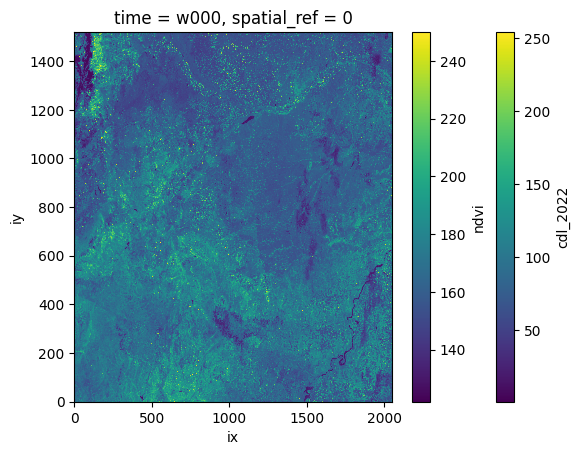

In [2]:
# 7. Visualization & metadata
# View the metadata, dimensions, and variables
print(cdl)
print(ndvi)
print(smap)

# Plot the CDL layer specifically for the configured year
cdl_var = f"cdl_{cdl_year}"
cdl[cdl_var].plot()

# Plot the NDVI for the very first week in the dataset
ndvi["ndvi"].isel(time=0).plot()

# Plot surface soil moisture (m³/m³) for the first week in the SMAP stack
smap["sm_surface"].isel(time=0).plot()

In [3]:
import matplotlib.pyplot as plt

# Define your crop values
CORN_VAL = 1
SOY_VAL = 5

# Create boolean masks (True where the crop exists, False everywhere else)
corn_mask = cdl[cdl_var] == CORN_VAL
soy_mask = cdl[cdl_var] == SOY_VAL

# Apply the masks to the NDVI cube using .where()
# This turns any pixel that ISN'T corn/soy into NaN (Not a Number) so it's ignored
ndvi_corn = ndvi["ndvi"].where(corn_mask)
ndvi_soy = ndvi["ndvi"].where(soy_mask)

In [4]:
# Calculate the mean across the spatial dimensions (iy, ix), leaving only 'time'
# skipna=True ensures the masked out non-crop pixels don't break the math
mean_corn_ndvi = ndvi_corn.mean(dim=["iy", "ix"], skipna=True)
mean_soy_ndvi = ndvi_soy.mean(dim=["iy", "ix"], skipna=True)

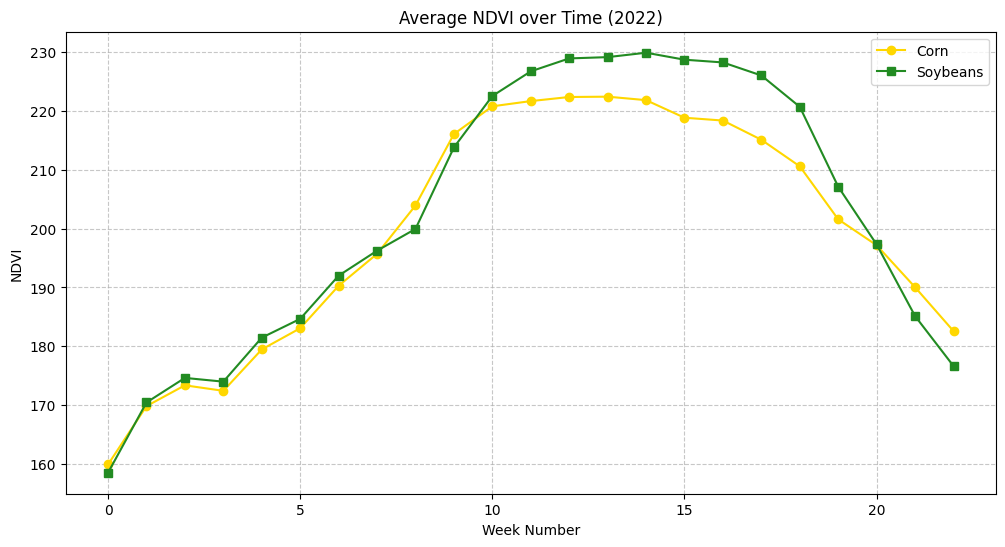

In [6]:
import matplotlib.pyplot as plt

# 1. Strip the "w" and convert the time labels to integers (e.g., 'w001' -> 1)
week_numbers = [int(str(t).replace("w", "")) for t in mean_corn_ndvi["time"].values]

# 2. Update the coordinates for both datasets
mean_corn_ndvi = mean_corn_ndvi.assign_coords(time=week_numbers)
mean_soy_ndvi = mean_soy_ndvi.assign_coords(time=week_numbers)

# 3. Now the plot will work perfectly!
plt.figure(figsize=(12, 6))

# Plot both time series
mean_corn_ndvi.plot(label="Corn", color="gold", marker="o")
mean_soy_ndvi.plot(label="Soybeans", color="forestgreen", marker="s")

plt.title(f"Average NDVI over Time ({ndvi_year})")
plt.xlabel("Week Number")
plt.ylabel("NDVI")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.show()

In [7]:
import numpy as np

# Find all the unique integer codes present in your CDL map for that year
unique_codes = np.unique(cdl[cdl_var])

print(f"Unique CDL codes in your map for {cdl_year}:")
print(unique_codes)

Unique CDL codes in your map for 2022:
[  1   4   5   6  13  21  22  23  24  27  28  29  31  32  33  36  37  39
  41  42  43  44  47  49  51  52  53  58  59  60  61  69 111 112 121 122
 123 124 131 141 142 143 152 176 190 195 205 206 225 228 236 240 254]


In [8]:
import pandas as pd

# 1. Convert each Xarray DataArray to a Pandas DataFrame
# We give the resulting data column a specific name so they don't both default to 'ndvi'
df_corn = mean_corn_ndvi.to_dataframe(name="corn_ndvi").reset_index()
df_soy = mean_soy_ndvi.to_dataframe(name="soy_ndvi").reset_index()

# 2. Merge them together on the 'time' column
df_ndvi = pd.merge(df_corn, df_soy, on="time")

# Optional: Rename 'time' to 'week' to be more descriptive
df_ndvi = df_ndvi.rename(columns={"time": "week"})

# Check out your new DataFrame
print(df_ndvi.head())

   week  spatial_ref_x   corn_ndvi  spatial_ref_y    soy_ndvi
0     0              0  159.899078              0  158.496841
1     1              0  169.816055              0  170.435486
2     2              0  173.354446              0  174.614120
3     3              0  172.417557              0  173.976562
4     4              0  179.454300              0  181.455139


In [9]:
# 1. Mask it in Xarray
wheat_mask = cdl[cdl_var] == 24
ndvi_wheat = ndvi["ndvi"].where(wheat_mask)

# 2. Squash it to a time series
mean_wheat_ndvi = ndvi_wheat.mean(dim=["iy", "ix"], skipna=True)

# 3. Add to your Pandas DataFrame
df_ndvi["wheat_ndvi"] = mean_wheat_ndvi.values

In [11]:
print(df_ndvi)

    week  spatial_ref_x   corn_ndvi  spatial_ref_y    soy_ndvi  wheat_ndvi
0      0              0  159.899078              0  158.496841  173.517578
1      1              0  169.816055              0  170.435486  188.278046
2      2              0  173.354446              0  174.614120  193.541733
3      3              0  172.417557              0  173.976562  195.276413
4      4              0  179.454300              0  181.455139  195.756836
5      5              0  183.057129              0  184.649948  201.115387
6      6              0  190.275864              0  191.992523  197.306595
7      7              0  195.699112              0  196.238266  188.873611
8      8              0  203.926834              0  199.939163  185.592316
9      9              0  216.068481              0  213.795074  181.180710
10    10              0  220.785034              0  222.536270  179.952209
11    11              0  221.669769              0  226.726089  177.397614
12    12              0  

In [12]:
df_ndvi = df_ndvi.drop(columns=['spatial_ref_x', 'spatial_ref_y'], errors='ignore')

print(df_ndvi.head())

   week   corn_ndvi    soy_ndvi  wheat_ndvi
0     0  159.899078  158.496841  173.517578
1     1  169.816055  170.435486  188.278046
2     2  173.354446  174.614120  193.541733
3     3  172.417557  173.976562  195.276413
4     4  179.454300  181.455139  195.756836


In [15]:
# Create a clean CDL dataframe with just the coordinates and the target year
cdl_df_clean = cdl_df[['iy', 'ix', f'cdl_{cdl_year}']].copy()

# Rename the column to something simple like 'crop_code'
cdl_df_clean = cdl_df_clean.rename(columns={f'cdl_{cdl_year}': 'crop_code'})

print("Clean CDL DataFrame:")
print(cdl_df_clean)

Clean CDL DataFrame:
           iy    ix  crop_code
0           0     0        152
1           0     1        152
2           0     2        152
3           0     3        176
4           0     4        152
...       ...   ...        ...
3112955  1519  2043          5
3112956  1519  2044          5
3112957  1519  2045          1
3112958  1519  2046        176
3112959  1519  2047          5

[3112960 rows x 3 columns]


In [16]:
# Create a clean NDVI dataframe
ndvi_df_clean = ndvi_df[['iy', 'ix', 'time', 'ndvi']].copy()

# Convert the 'time' strings (e.g., 'w001') into integer week numbers
ndvi_df_clean['week'] = ndvi_df_clean['time'].astype(str).str.replace('w', '').astype(int)

# Drop the old string column and reorganize
ndvi_df_clean = ndvi_df_clean[['iy', 'ix', 'week', 'ndvi']]

print("\nClean NDVI DataFrame:")
print(ndvi_df_clean)


Clean NDVI DataFrame:
            iy    ix  week   ndvi
0            0     0     0  178.0
1            0     1     0  178.0
2            0     2     0  175.0
3            0     3     0  173.0
4            0     4     0  172.0
...        ...   ...   ...    ...
71598075  1519  2043    22  176.0
71598076  1519  2044    22  175.0
71598077  1519  2045    22  175.0
71598078  1519  2046    22  175.0
71598079  1519  2047    22  174.0

[71598080 rows x 4 columns]


In [17]:
# 1. Merge the crop codes into the NDVI data 
# (This might take a few seconds because of the 71.5 million rows!)
merged_df = pd.merge(ndvi_df_clean, cdl_df_clean, on=['iy', 'ix'])

# 2. Filter out just the pixels we care about
corn_pixels = merged_df[merged_df['crop_code'] == 1]
soy_pixels = merged_df[merged_df['crop_code'] == 5]

# 3. Group by week and calculate the mean NDVI
corn_timeseries = corn_pixels.groupby('week')['ndvi'].mean().reset_index()
corn_timeseries = corn_timeseries.rename(columns={'ndvi': 'corn_ndvi'})

soy_timeseries = soy_pixels.groupby('week')['ndvi'].mean().reset_index()
soy_timeseries = soy_timeseries.rename(columns={'ndvi': 'soy_ndvi'})

# 4. Combine them into one final summary DataFrame
final_timeseries = pd.merge(corn_timeseries, soy_timeseries, on='week')

print("\nFinal Aggregated Time Series:")
print(final_timeseries)


Final Aggregated Time Series:
    week   corn_ndvi    soy_ndvi
0      0  159.899048  158.496841
1      1  169.816055  170.435486
2      2  173.354492  174.614120
3      3  172.417526  173.976562
4      4  179.454315  181.455139
5      5  183.057114  184.649948
6      6  190.275879  191.992523
7      7  195.699188  196.238266
8      8  203.926849  199.939194
9      9  216.068466  213.795029
10    10  220.785049  222.536224
11    11  221.669861  226.726089
12    12  222.365250  228.924484
13    13  222.420807  229.142517
14    14  221.830551  229.891983
15    15  218.841385  228.706238
16    16  218.362564  228.240616
17    17  215.095383  226.024780
18    18  210.580612  220.694733
19    19  201.569061  207.117172
20    20  197.164749  197.293289
21    21  190.026306  185.125198
22    22  182.572388  176.630539


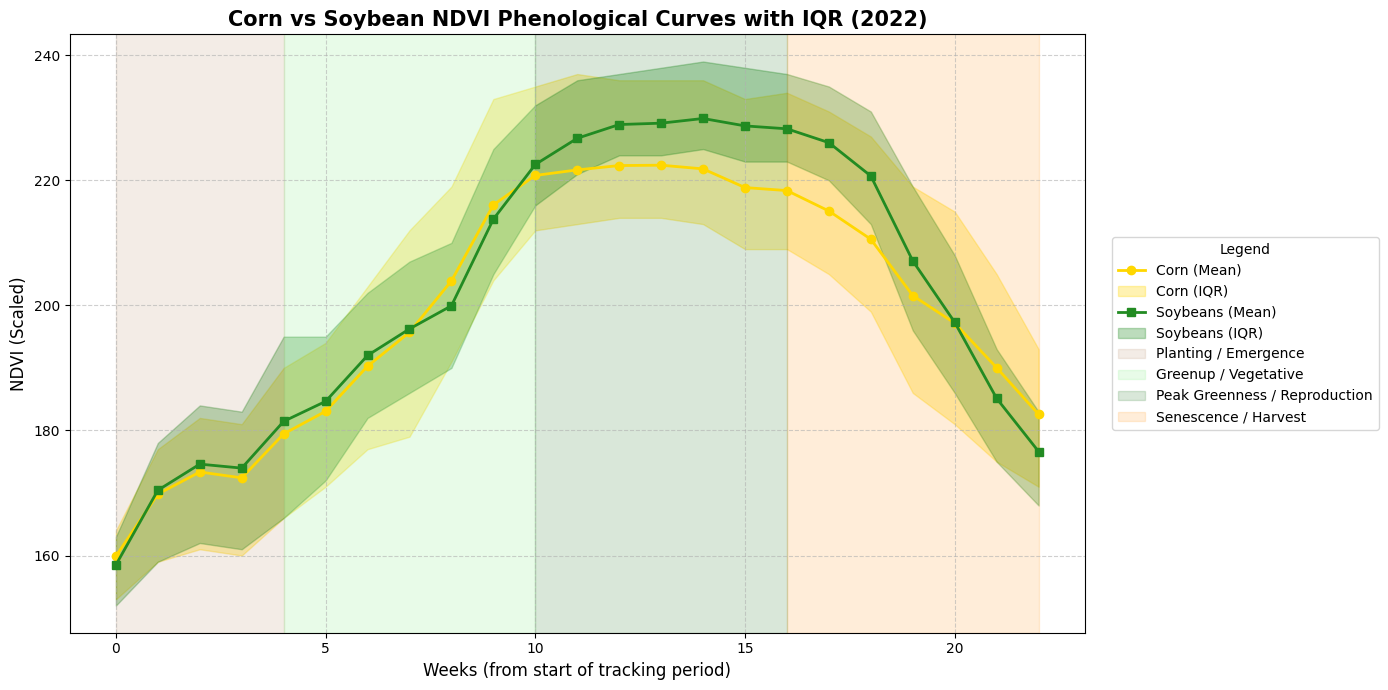

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Calculate Mean and IQR (25th and 75th percentiles) using Pandas aggregation
corn_stats = corn_pixels.groupby('week').agg(
    corn_mean=('ndvi', 'mean'),
    corn_q25=('ndvi', lambda x: x.quantile(0.25)),
    corn_q75=('ndvi', lambda x: x.quantile(0.75))
).reset_index()

soy_stats = soy_pixels.groupby('week').agg(
    soy_mean=('ndvi', 'mean'),
    soy_q25=('ndvi', lambda x: x.quantile(0.25)),
    soy_q75=('ndvi', lambda x: x.quantile(0.75))
).reset_index()

# Merge into one clean summary table
final_stats = pd.merge(corn_stats, soy_stats, on='week')

# 2. Plotting the Phenological Curves with Uncertainty Bands
fig, ax = plt.subplots(figsize=(14, 7))

# Plot Corn
ax.plot(final_stats['week'], final_stats['corn_mean'], label='Corn (Mean)', color='gold', linewidth=2, marker='o')
ax.fill_between(final_stats['week'], final_stats['corn_q25'], final_stats['corn_q75'], color='gold', alpha=0.3, label='Corn (IQR)')

# Plot Soybeans
ax.plot(final_stats['week'], final_stats['soy_mean'], label='Soybeans (Mean)', color='forestgreen', linewidth=2, marker='s')
ax.fill_between(final_stats['week'], final_stats['soy_q25'], final_stats['soy_q75'], color='forestgreen', alpha=0.3, label='Soybeans (IQR)')

# 3. Highlight Key Growing Stages (Approximate timing based on standard Corn Belt seasons)
ax.axvspan(0, 4, color='saddlebrown', alpha=0.1, label='Planting / Emergence')
ax.axvspan(4, 10, color='lightgreen', alpha=0.2, label='Greenup / Vegetative')
ax.axvspan(10, 16, color='darkgreen', alpha=0.15, label='Peak Greenness / Reproduction')
ax.axvspan(16, 22, color='darkorange', alpha=0.15, label='Senescence / Harvest')

# 4. Formatting the Figure
ax.set_title(f"Corn vs Soybean NDVI Phenological Curves with IQR ({ndvi_year})", fontsize=15, fontweight='bold')
ax.set_xlabel("Weeks (from start of tracking period)", fontsize=12)
ax.set_ylabel("NDVI (Scaled)", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.6)

# Move legend outside the plot so it doesn't cover the data
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title="Legend", fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
import optax

import jax
import jax.numpy as jnp
import numpyro
from numpyro import distributions as dist

# Import the Squared Exponential approximation instead of Matern
from numpyro.contrib.hsgp.approximation import hsgp_squared_exponential

@jax.tree_util.register_pytree_node_class
class HSGP_Phenology_Model:
    def __init__(self, m: list[int], L: list[float], baseline_ndvi: float):
        self.m = m 
        self.L = L 
        self.baseline_ndvi = baseline_ndvi 

    def model(self, X: jax.Array, y: jax.Array | None = None):
        # 1. Priors for GP Hyperparameters
        amplitude = numpyro.sample("amplitude", dist.LogNormal(0.0, 1.0)) 
        length = numpyro.sample("lengthscale", dist.Exponential(jnp.ones(1))) 
        sigma = numpyro.sample("sigma", dist.HalfNormal(10.0))

        # 2. The HSGP approximation using the Squared Exponential Kernel
        # Notice we dropped the 'nu=2.5' parameter here
        f_centered = hsgp_squared_exponential(X, alpha=amplitude, length=length, ell=self.L, m=self.m) 
        f = numpyro.deterministic("f_star", f_centered + self.baseline_ndvi) 
        
        # 3. Normal Likelihood for continuous NDVI data
        site = "y" if y is not None else "y_test"
        numpyro.sample(site, dist.Normal(loc=f, scale=sigma), obs=y)

    def tree_flatten(self):
        children = ()  
        aux_data = (self.L, self.m, self.baseline_ndvi) 
        return (children, aux_data)

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        return cls(*children, **aux_data)=

In [20]:
# Convert Pandas columns to JAX arrays
weeks_jax = jnp.array(corn_pixels['week'].values)
ndvi_jax = jnp.array(corn_pixels['ndvi'].values)

# Setup SVI
guide = AutoNormal(hsgp_phenology_model) # Mean-field variational approximation
optimizer = optax.adam(learning_rate=0.01)
svi = SVI(hsgp_phenology_model, guide, optimizer, loss=Trace_ELBO())

# Initialize state
rng_key = jax.random.PRNGKey(42)
svi_state = svi.init(rng_key, weeks=weeks_jax, ndvi=ndvi_jax)

# JIT compile the update step for massive speed
@jax.jit
def step(state, w, y):
    return svi.update(state, weeks=w, ndvi=y)

# Training Loop
num_epochs = 2000
print("Optimizing Variational Posterior (SVI)...")

for i in range(num_epochs):
    svi_state, loss = step(svi_state, weeks_jax, ndvi_jax)
    if i % 500 == 0:
        print(f"Epoch {i} | Loss: {loss:.2f}")

print("SVI Optimization Complete!")

W0411 10:52:44.460456  284523 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Optimizing Variational Posterior (SVI)...
Epoch 0 | Loss: 603597307904.00


KeyboardInterrupt: 

In [ ]:
from numpyro.infer import Predictive

# Generate a continuous smooth curve for the X-axis
weeks_continuous = jnp.linspace(0, 23, 200)

# Sample from the trained Variational Guide
predictive = Predictive(hsgp_phenology_model, guide=guide, params=svi.get_params(svi_state), num_samples=1000)
posterior_predictive = predictive(jax.random.PRNGKey(1), weeks=weeks_continuous)

# Reconstruct the curve from the sampled parameters
baseline_samples = posterior_predictive["baseline"]
beta_samples = posterior_predictive["beta"]
alpha_samples = posterior_predictive["alpha"]
rho_samples = posterior_predictive["rho"]

# (You would run the basis function math here one last time using the extracted samples 
# to calculate the mean and 95% Confidence Intervals for your final Matplotlib plot).